# ESZA019 – Visão Computacional
## Laboratório 6 – Depth Map: Mapa de Profundidade

**Integrantes:**  
- Luana Fernandes Recucci
- Lucas Merino
- Victor Parpinelli Ananias da Silva

**Data de realização:** 20/07/2026 
**Data de publicação:** 22/07/2026

## 1. Objetivos

- Compreender mapa de disparidade, retificação e mapa de profundidade.
- Calibrar e utilizar a câmera estéreo construída no laboratório anterior.
- Ajustar os parâmetros do algoritmo Block Matching do OpenCV.
- Determinar experimentalmente a relação entre profundidade e disparidade.
- Medir a distância de objetos e comparar os resultados com valores reais.
- Elaborar um programa que forneça a distância da câmera até um objeto específico.

## 2. Fundamentação teórica

### 2.1 Retificação de imagens

A retificação transforma as imagens esquerda e direita para que pontos correspondentes fiquem aproximadamente na mesma linha horizontal. Isso simplifica a busca de correspondências.

### 2.2 Disparidade

Para imagens retificadas:

\[
d=x_L-x_R
\]

Objetos próximos tendem a apresentar maior disparidade, enquanto objetos distantes apresentam menor disparidade.

### 2.3 Profundidade

No modelo geométrico ideal:

\[
Z=\frac{fB}{d}
\]

No procedimento experimental foi utilizada uma relação ajustada:

\[
Z=M\left(\frac{1}{d_n}\right)+C
\]

em que \(d_n\) é a disparidade normalizada. O código original calcula \(M\) e \(C\), mas grava apenas \(M\) no XML e usa \(Z=M/d_n\).

### 2.4 Block Matching

O `StereoBM` compara blocos da imagem esquerda com blocos da imagem direita ao longo das linhas epipolares. Os parâmetros principais são `numDisparities`, `blockSize`, filtros prévios, limiar de textura, razão de unicidade e filtros de speckle.

## 3. Diagrama de blocos

```text
Duas webcams fixadas
        ↓
Captura do tabuleiro
        ↓
Calibração individual
        ↓
Calibração estéreo
        ↓
Mapas de retificação
        ↓
Captura das imagens
        ↓
Conversão para cinza
        ↓
Retificação
        ↓
StereoBM
        ↓
Mapa de disparidade
        ↓
Calibração profundidade × disparidade
        ↓
Mapa de profundidade
        ↓
Medição e detecção de obstáculos
```

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from IPython.display import display, Image

PASTA_DADOS = Path("data")
PASTA_IMAGENS = Path("imagens")
PASTA_PROGRAMAS = Path("programas")

print("Versão do OpenCV:", cv2.__version__)

## 4. Captura e calibração estéreo

Os programas `capture_images_abc.py` e `calibrate_abc.py` usam um tabuleiro de **8 × 6 cantos internos**. A captura salva pares de imagens, e a calibração gera quatro mapas de retificação em `params_py.xml`.

O XML original armazena apenas:

- `Left_Stereo_Map_x`;
- `Left_Stereo_Map_y`;
- `Right_Stereo_Map_x`;
- `Right_Stereo_Map_y`.

As matrizes intrínsecas, rotação, translação, matriz essencial, matriz fundamental e matriz Q são calculadas, mas não são salvas pelo programa original.

In [ ]:
print("Programa de captura:", PASTA_PROGRAMAS / "capture_images_abc.py")
print("Programa de calibração:", PASTA_PROGRAMAS / "calibrate_abc.py")
print("Arquivo esperado:", PASTA_DADOS / "params_py.xml")

## 5. Mapa de disparidade

O exemplo `lab6b_stereoBM_exemplo.py` utiliza `StereoBM` com `numDisparities=16` e `blockSize=15`.

A saída de `StereoBM.compute` é uma matriz inteira de 16 bits com disparidade multiplicada por 16. No código do laboratório, a normalização é:

\[
d_n=rac{d/16-d_{min}}{N_d}
\]

In [ ]:
def criar_stereo_bm(parametros):
    stereo = cv2.StereoBM_create()
    stereo.setNumDisparities(int(parametros["numDisparities"]))
    stereo.setBlockSize(int(parametros["blockSize"]))
    stereo.setPreFilterType(int(parametros["preFilterType"]))
    stereo.setPreFilterSize(int(parametros["preFilterSize"]))
    stereo.setPreFilterCap(int(parametros["preFilterCap"]))
    stereo.setTextureThreshold(int(parametros["textureThreshold"]))
    stereo.setUniquenessRatio(int(parametros["uniquenessRatio"]))
    stereo.setSpeckleRange(int(parametros["speckleRange"]))
    stereo.setSpeckleWindowSize(int(parametros["speckleWindowSize"]))
    stereo.setDisp12MaxDiff(int(parametros["disp12MaxDiff"]))
    stereo.setMinDisparity(int(parametros["minDisparity"]))
    return stereo

PARAMETROS_INICIAIS = {
    "numDisparities": 16,
    "blockSize": 15,
    "preFilterType": 1,
    "preFilterSize": 9,
    "preFilterCap": 5,
    "textureThreshold": 10,
    "uniquenessRatio": 15,
    "speckleRange": 0,
    "speckleWindowSize": 6,
    "disp12MaxDiff": 5,
    "minDisparity": 5,
}
PARAMETROS_INICIAIS

## 6. Calibração profundidade × disparidade

O programa `disparity2depth_calib.py` registra pares de profundidade e disparidade. O objeto é inicialmente colocado a 230 cm e deslocado em passos de 40 cm até aproximadamente 70 cm.

O gráfico experimental fornecido é apresentado abaixo.

In [ ]:
grafico = PASTA_IMAGENS / "disparity_depth.png"
if grafico.exists():
    display(Image(filename=str(grafico), width=1000))
else:
    print("Gráfico não encontrado.")

O gráfico mostra que a profundidade diminui quando a disparidade aumenta. A relação direta é curva, enquanto a relação entre profundidade e inverso da disparidade se aproxima de uma reta.

In [ ]:
pares_calibracao = np.array([
    # [profundidade_cm, disparidade_normalizada],
], dtype=float)

if len(pares_calibracao) >= 2:
    z = pares_calibracao[:, 0]
    disp = pares_calibracao[:, 1]
    validos = disp > 0
    A = np.column_stack((1/disp[validos], np.ones(np.sum(validos))))
    M, C = np.linalg.lstsq(A, z[validos], rcond=None)[0]
    print(f"M = {M:.6f}")
    print(f"C = {C:.6f}")
else:
    print("Preencha os pares medidos para recalcular M e C.")

## 7. Conversão para mapa de profundidade

In [ ]:
def disparidade_para_profundidade(disparidade_normalizada, M, C=0.0,
                                  profundidade_min=10.0,
                                  profundidade_max=400.0):
    disp = np.asarray(disparidade_normalizada, dtype=np.float32)
    profundidade = np.full_like(disp, np.nan, dtype=np.float32)

    validos = np.isfinite(disp) & (disp > 0)
    profundidade[validos] = M / disp[validos] + C

    dentro_faixa = (
        validos
        & (profundidade >= profundidade_min)
        & (profundidade <= profundidade_max)
    )
    profundidade[~dentro_faixa] = np.nan
    return profundidade

## 8. Medidas de distância

No arquivo `medidas.txt`, `r` representa a distância real e `p` a distância prevista. Foram medidos três objetos: livro, xadrez e página.

In [ ]:
medidas = {
    "Livro": [(83,86),(63,90),(101,120),(127,150),(90,106),(57,90)],
    "Xadrez": [(94,100),(133,147),(81,84),(52,86),(167,130)],
    "Página": [(121,140),(136,140),(157,170),(186,160),(60,127)],
}

linhas = []
for objeto, pares in medidas.items():
    for numero, (real, prevista) in enumerate(pares, 1):
        erro_abs = abs(prevista-real)
        erro_pct = erro_abs/real*100
        linhas.append({
            "Objeto": objeto,
            "Medição": numero,
            "Distância real (cm)": real,
            "Distância prevista (cm)": prevista,
            "Erro absoluto (cm)": erro_abs,
            "Erro percentual (%)": erro_pct
        })

tabela_medidas = pd.DataFrame(linhas)
tabela_medidas.round(2)

In [ ]:
resumo_objetos = tabela_medidas.groupby("Objeto").agg(
    Número_de_medidas=("Medição","count"),
    Distância_real_média_cm=("Distância real (cm)","mean"),
    Distância_prevista_média_cm=("Distância prevista (cm)","mean"),
    MAE_cm=("Erro absoluto (cm)","mean"),
    MAPE_percentual=("Erro percentual (%)","mean")
).reset_index()

resumo_objetos.round(2)

In [ ]:
mae_geral = tabela_medidas["Erro absoluto (cm)"].mean()
mape_geral = tabela_medidas["Erro percentual (%)"].mean()
rmse_geral = np.sqrt(np.mean(
    (tabela_medidas["Distância prevista (cm)"]
     - tabela_medidas["Distância real (cm)"])**2
))

print(f"MAE geral: {mae_geral:.2f} cm")
print(f"MAPE geral: {mape_geral:.2f}%")
print(f"RMSE geral: {rmse_geral:.2f} cm")

In [ ]:
plt.figure(figsize=(9,6))
plt.scatter(
    tabela_medidas["Distância real (cm)"],
    tabela_medidas["Distância prevista (cm)"]
)
mn = min(tabela_medidas["Distância real (cm)"].min(),
         tabela_medidas["Distância prevista (cm)"].min())
mx = max(tabela_medidas["Distância real (cm)"].max(),
         tabela_medidas["Distância prevista (cm)"].max())
plt.plot([mn,mx],[mn,mx], linestyle="--")
plt.xlabel("Distância real (cm)")
plt.ylabel("Distância prevista (cm)")
plt.title("Distância real × distância prevista")
plt.grid(True)
plt.show()

### 8.1 Análise dos resultados

Para as 16 medições fornecidas:

- **MAE geral:** 21.50 cm;
- **MAPE geral:** 26.24%;
- **RMSE geral:** 26.75 cm.

O sistema acompanha a tendência de distância, mas apresenta erros relevantes em algumas amostras. As diferenças podem ser associadas a superfícies com pouca textura, iluminação, seleção do ponto no mapa, ruído de correspondência, bordas dos objetos e calibração incompleta da relação profundidade–disparidade.
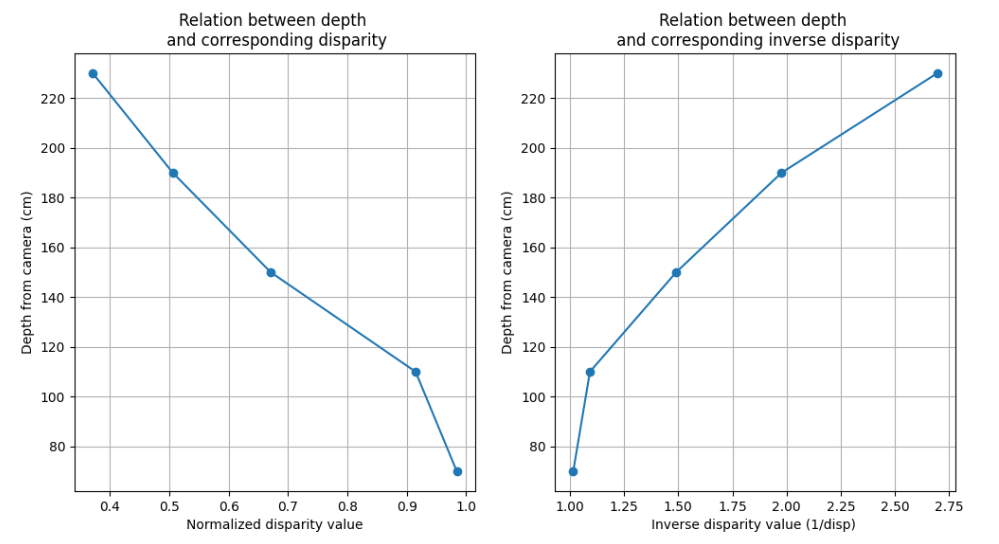

## 9. Detecção de obstáculos

O programa `obstacle_avoidance.py` cria uma máscara para regiões mais próximas que um limite de segurança, procura o maior contorno e calcula a profundidade média dessa região.

In [ ]:
def detectar_obstaculo(depth_map, imagem, limite_cm=100.0):
    depth_valid = np.nan_to_num(
        depth_map, nan=0.0, posinf=0.0, neginf=0.0
    ).astype(np.float32)

    mask = cv2.inRange(depth_valid, 10.0, float(limite_cm))
    area_min = 0.01 * mask.shape[0] * mask.shape[1]
    distancia = None

    if np.count_nonzero(mask) > area_min:
        contornos, _ = cv2.findContours(
            mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )
        if contornos:
            maior = max(contornos, key=cv2.contourArea)
            if cv2.contourArea(maior) > area_min:
                x, y, w, h = cv2.boundingRect(maior)
                mask_obj = np.zeros_like(mask)
                cv2.drawContours(mask_obj, [maior], -1, 255, -1)
                media, _ = cv2.meanStdDev(depth_valid, mask=mask_obj)
                distancia = float(media[0,0])
                cv2.rectangle(imagem, (x,y), (x+w,y+h), (0,0,255), 2)
                cv2.putText(
                    imagem, f"Objeto a {distancia:.1f} cm",
                    (x, max(30,y-10)), cv2.FONT_HERSHEY_SIMPLEX,
                    0.7, (0,0,255), 2
                )
    else:
        cv2.putText(
            imagem, "SEGURO", (40,60),
            cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0,255,0), 3
        )
    return imagem, distancia

## 10. Programa final: distância até um objeto específico

A aplicação final mede a distância de um livro ou página colocado na região central da imagem. Em vez de usar um único pixel, é utilizada a mediana das profundidades válidas em uma região de interesse.

In [ ]:
def carregar_mapas_retificacao(caminho_xml):
    fs = cv2.FileStorage(str(caminho_xml), cv2.FILE_STORAGE_READ)
    mapas = {
        "Lx": fs.getNode("Left_Stereo_Map_x").mat(),
        "Ly": fs.getNode("Left_Stereo_Map_y").mat(),
        "Rx": fs.getNode("Right_Stereo_Map_x").mat(),
        "Ry": fs.getNode("Right_Stereo_Map_y").mat(),
    }
    fs.release()
    if any(v is None for v in mapas.values()):
        raise ValueError("Mapas de retificação ausentes no XML.")
    return mapas

def distancia_regiao_central(depth_map, largura=100, altura=100):
    h, w = depth_map.shape
    x1, x2 = w//2-largura//2, w//2+largura//2
    y1, y2 = h//2-altura//2, h//2+altura//2
    roi = depth_map[y1:y2, x1:x2]
    validos = roi[np.isfinite(roi)]
    distancia = None if validos.size == 0 else float(np.median(validos))
    return distancia, (x1,y1,x2,y2)

In [ ]:
# Execução local com as webcams.
CAMERA_ESQUERDA = 0
CAMERA_DIREITA = 1
M_CALIBRADO = None   # preencher com o valor obtido
C_CALIBRADO = 0.0

if M_CALIBRADO is None:
    print("Preencha M_CALIBRADO antes de executar.")
else:
    mapas = carregar_mapas_retificacao(PASTA_DADOS / "params_py.xml")
    stereo = criar_stereo_bm(PARAMETROS_INICIAIS)

    camL = cv2.VideoCapture(CAMERA_ESQUERDA)
    camR = cv2.VideoCapture(CAMERA_DIREITA)

    try:
        while True:
            retL, imgL = camL.read()
            retR, imgR = camR.read()
            if not retL or not retR:
                break

            grayL = cv2.cvtColor(imgL, cv2.COLOR_BGR2GRAY)
            grayR = cv2.cvtColor(imgR, cv2.COLOR_BGR2GRAY)

            rectL = cv2.remap(grayL, mapas["Lx"], mapas["Ly"],
                              cv2.INTER_LANCZOS4, cv2.BORDER_CONSTANT)
            rectR = cv2.remap(grayR, mapas["Rx"], mapas["Ry"],
                              cv2.INTER_LANCZOS4, cv2.BORDER_CONSTANT)

            disp_raw = stereo.compute(rectL, rectR).astype(np.float32)
            disp_norm = (
                disp_raw/16.0 - PARAMETROS_INICIAIS["minDisparity"]
            ) / PARAMETROS_INICIAIS["numDisparities"]

            depth = disparidade_para_profundidade(
                disp_norm, M_CALIBRADO, C_CALIBRADO
            )

            distancia, (x1,y1,x2,y2) = distancia_regiao_central(depth)
            saida = imgL.copy()
            cv2.rectangle(saida, (x1,y1), (x2,y2), (0,255,0), 2)

            texto = (
                f"Distancia: {distancia:.1f} cm"
                if distancia is not None else "Distancia indisponivel"
            )
            cv2.putText(saida, texto, (20,40),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0,255,0), 2)

            cv2.imshow("Objeto especifico", saida)
            cv2.imshow("Disparidade", disp_norm)

            if cv2.waitKey(1) & 0xFF == 27:
                break
    finally:
        camL.release()
        camR.release()
        cv2.destroyAllWindows()

## 11. Discussão geral

A relação inversa entre profundidade e disparidade foi observada no gráfico. O sistema conseguiu produzir estimativas para livro, xadrez e página, mas a precisão variou.

## 12. Conclusões

O laboratório permitiu implementar as etapas necessárias para obter profundidade com uma câmera estéreo. Após a calibração e a retificação, o algoritmo `StereoBM` produziu um mapa de disparidade. A calibração experimental confirmou que a profundidade é aproximadamente proporcional ao inverso da disparidade.

As medições demonstraram a viabilidade do método, embora os erros indiquem a necessidade de melhorar a sintonia, a montagem e a forma de seleção das regiões medidas. O programa final foi estruturado para fornecer a distância de um objeto específico usando a mediana de uma região central, abordagem mais robusta que a leitura de um único pixel.

## 13. Declaração sobre o uso de Inteligência Artificial Generativa

Foi utilizada a ferramenta **ChatGPT, da OpenAI**, como apoio na organização do relatório em Jupyter Notebook, revisão textual, análise dos arquivos fornecidos e estruturação dos códigos. Os autores revisaram o conteúdo e permanecem responsáveis pela versão final, pelos resultados, pelas referências e por eventuais imprecisões.

## 14. Referências

[1] LEARNOPENCV. *Making a Low-Cost Stereo Camera Using OpenCV*.  
[2] LEARNOPENCV. *Introduction to Epipolar Geometry and Stereo Vision*.  
[3] LEARNOPENCV. *Stereo Camera Depth Estimation With OpenCV*.  
[4] OPENCV. *Depth Map from Stereo Images*.  
[5] LOOP, C.; ZHANG, Z. Computing Rectifying Homographies for Stereo Vision. IEEE CVPR, 1999.  
[6] LEARNOPENCV. *Geometry of Image Formation*.